In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")

print("Path to dataset files:", path)

100%|██████████| 62.5M/62.5M [00:02<00:00, 30.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/snehaanbhawal/resume-dataset/versions/1


In [ ]:
# Install required libraries
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn wordcloud nltk -q
!pip install sentence-transformers -q

In [ ]:
!pip install kagglehub scikit-learn pandas numpy nltk

import kagglehub
import pandas as pd
import numpy as np
import os
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Download dataset
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")

print("Dataset path:", path)

# Load CSV file
files = os.listdir(path)
print("Files in dataset path:", files)

csv_file = None
for root, _, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith(".csv"):
            csv_file = os.path.join(root, filename)
            break
    if csv_file:
        break

if csv_file:
    print(f"Found CSV file: {csv_file}")
    df = pd.read_csv(csv_file)
    # View dataset
    print("DataFrame head:")
    print(df.head())
else:
    print("Error: No CSV file found in the dataset.")

Using Colab cache for faster access to the 'resume-dataset' dataset.
Dataset path: /kaggle/input/resume-dataset
Files in dataset path: ['Resume', 'data']
Found CSV file: /kaggle/input/resume-dataset/Resume/Resume.csv
DataFrame head:
         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Use the dataset uploaded in Step 2
df = df.copy()
df.dropna(subset=['Resume_str', 'Category'], inplace=True)
df.reset_index(drop=True, inplace=True)

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head(3)

Shape: (2484, 4)

Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
# Check for nulls and duplicates
print("Null values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nNumber of categories:", df['Category'].nunique())
print("\nCategories:\n", df['Category'].unique())

Null values:
 ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Duplicate rows: 0

Number of categories: 24

Categories:
 ['HR' 'DESIGNER' 'INFORMATION-TECHNOLOGY' 'TEACHER' 'ADVOCATE'
 'BUSINESS-DEVELOPMENT' 'HEALTHCARE' 'FITNESS' 'AGRICULTURE' 'BPO' 'SALES'
 'CONSULTANT' 'DIGITAL-MEDIA' 'AUTOMOBILE' 'CHEF' 'FINANCE' 'APPAREL'
 'ENGINEERING' 'ACCOUNTANT' 'CONSTRUCTION' 'PUBLIC-RELATIONS' 'BANKING'
 'ARTS' 'AVIATION']


/tmp/ipykernel_4388/1671476805.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')


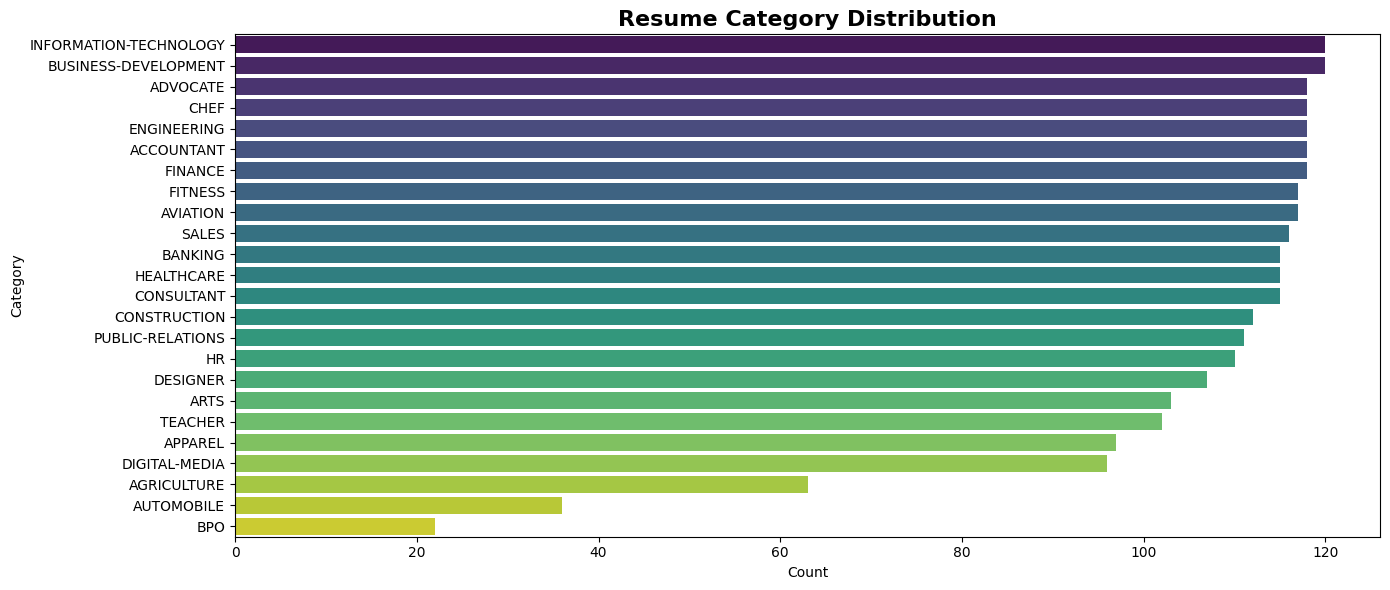

In [ ]:
# Category Distribution
plt.figure(figsize=(14, 6))
category_counts = df['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Resume Category Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

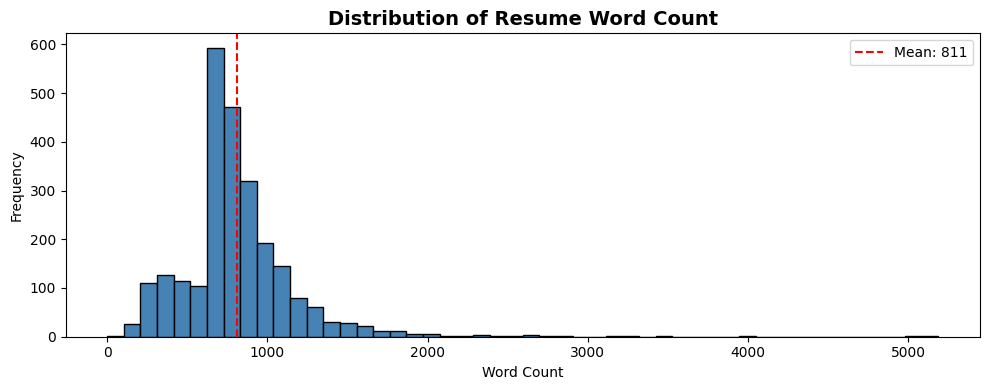

In [ ]:
# Resume Length Distribution
df['resume_length'] = df['Resume_str'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
plt.hist(df['resume_length'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Resume Word Count', fontsize=14, fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.axvline(df['resume_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['resume_length'].mean():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

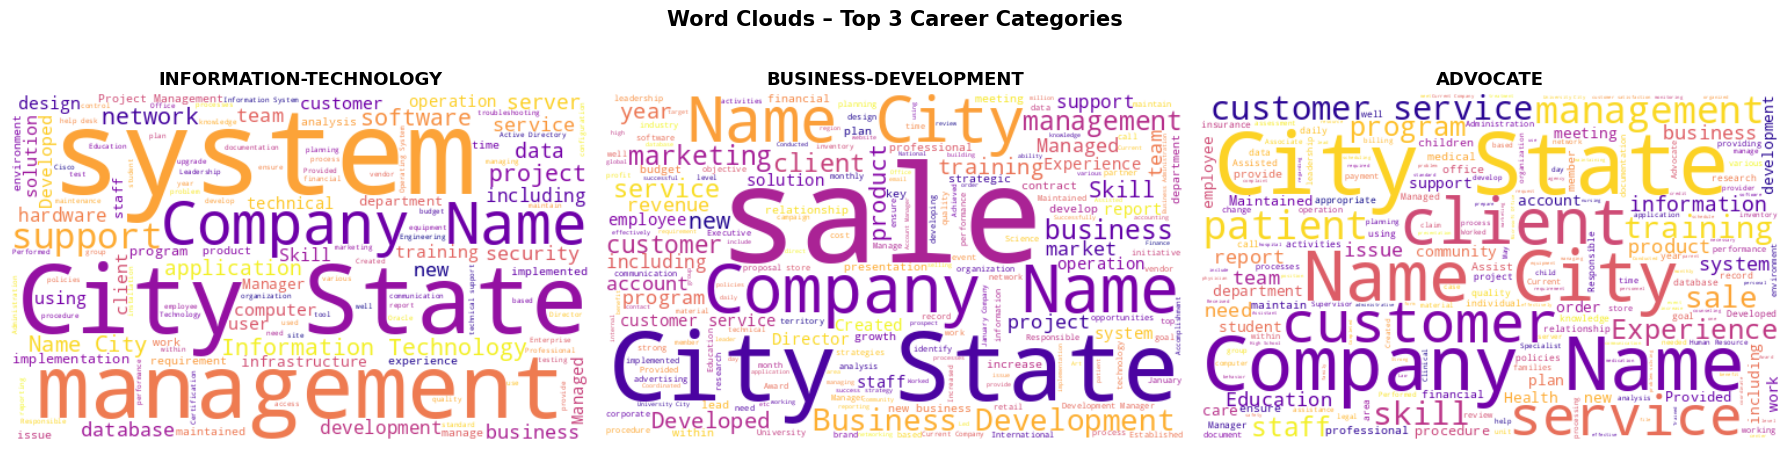

In [ ]:
# WordCloud for top 3 categories
top_categories = df['Category'].value_counts().index[:3]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cat in zip(axes, top_categories):
    text = ' '.join(df[df['Category'] == cat]['Resume_str'].astype(str))
    wc = WordCloud(width=500, height=300, background_color='white', colormap='plasma').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(cat, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Clouds – Top 3 Career Categories', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

text preprocessing

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_resume(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', ' ', text)          # Remove URLs
    text = re.sub(r'<.*?>', ' ', text)                     # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)              # Keep only letters
    text = text.lower()                                     # Lowercase
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens      # Lemmatize + stopword removal
              if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['cleaned_resume'] = df['Resume_str'].apply(clean_resume)
print("✅ Text preprocessing complete!")
print("\nSample cleaned resume (first 300 chars):")
print(df['cleaned_resume'].iloc[0][:300])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ Text preprocessing complete!

Sample cleaned resume (first 300 chars):
administrator marketing associate administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customer focused team strives instill shared enthusiastic commitment customer service highlight focused customer satisfaction te


label encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])

# Label mapping
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:", label_map)

X = df['cleaned_resume']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")

Label Mapping: {'ACCOUNTANT': np.int64(0), 'ADVOCATE': np.int64(1), 'AGRICULTURE': np.int64(2), 'APPAREL': np.int64(3), 'ARTS': np.int64(4), 'AUTOMOBILE': np.int64(5), 'AVIATION': np.int64(6), 'BANKING': np.int64(7), 'BPO': np.int64(8), 'BUSINESS-DEVELOPMENT': np.int64(9), 'CHEF': np.int64(10), 'CONSTRUCTION': np.int64(11), 'CONSULTANT': np.int64(12), 'DESIGNER': np.int64(13), 'DIGITAL-MEDIA': np.int64(14), 'ENGINEERING': np.int64(15), 'FINANCE': np.int64(16), 'FITNESS': np.int64(17), 'HEALTHCARE': np.int64(18), 'HR': np.int64(19), 'INFORMATION-TECHNOLOGY': np.int64(20), 'PUBLIC-RELATIONS': np.int64(21), 'SALES': np.int64(22), 'TEACHER': np.int64(23)}

Train size: 1987 | Test size: 497


**1. TF-IDF + ML**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Feature Matrix Shape (Train):", X_train_tfidf.shape)

TF-IDF Feature Matrix Shape (Train): (1987, 5000)


In [ ]:
# Train & Evaluate Multiple ML Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=5, random_state=42),
    'Linear SVM':          LinearSVC(max_iter=2000, C=1.0, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Naive Bayes':         MultinomialNB(alpha=0.1)
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n{'='*50}")
    print(f"  Model: {name}")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print('='*50)
    print(classification_report(y_test, preds, target_names=le.classes_))


  Model: Logistic Regression
  Accuracy: 0.6881 (68.81%)
                        precision    recall  f1-score   support

            ACCOUNTANT       0.77      0.83      0.80        24
              ADVOCATE       0.48      0.58      0.53        24
           AGRICULTURE       0.86      0.46      0.60        13
               APPAREL       0.67      0.32      0.43        19
                  ARTS       0.42      0.38      0.40        21
            AUTOMOBILE       1.00      0.14      0.25         7
              AVIATION       0.90      0.75      0.82        24
               BANKING       0.76      0.70      0.73        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.66      0.88      0.75        24
                  CHEF       0.85      0.71      0.77        24
          CONSTRUCTION       0.74      0.77      0.76        22
            CONSULTANT       0.67      0.43      0.53        23
              DESIGNER       0.89      0.81  

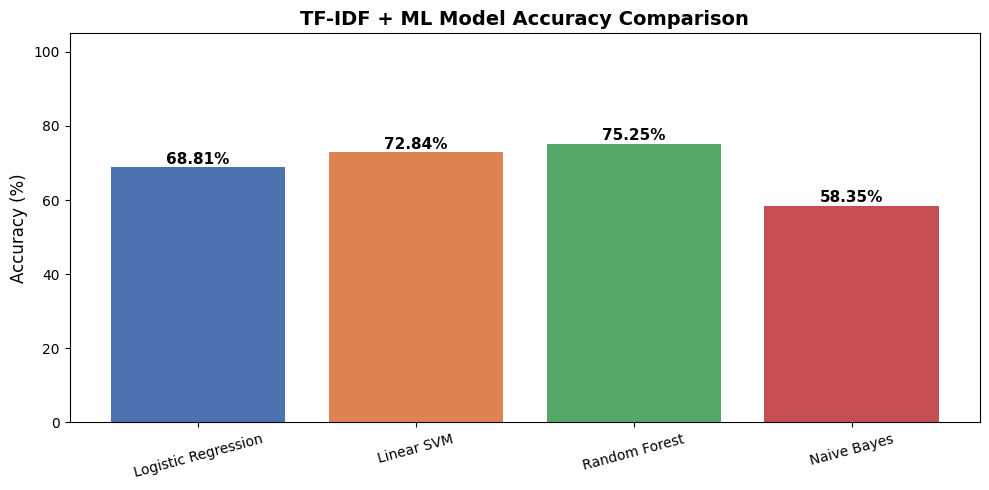

In [ ]:
# Accuracy Comparison Chart
plt.figure(figsize=(10, 5))
bars = plt.bar(results.keys(), [v*100 for v in results.values()],
               color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.ylim(0, 105)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('TF-IDF + ML Model Accuracy Comparison', fontsize=14, fontweight='bold')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val*100:.2f}%', ha='center', fontsize=11, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

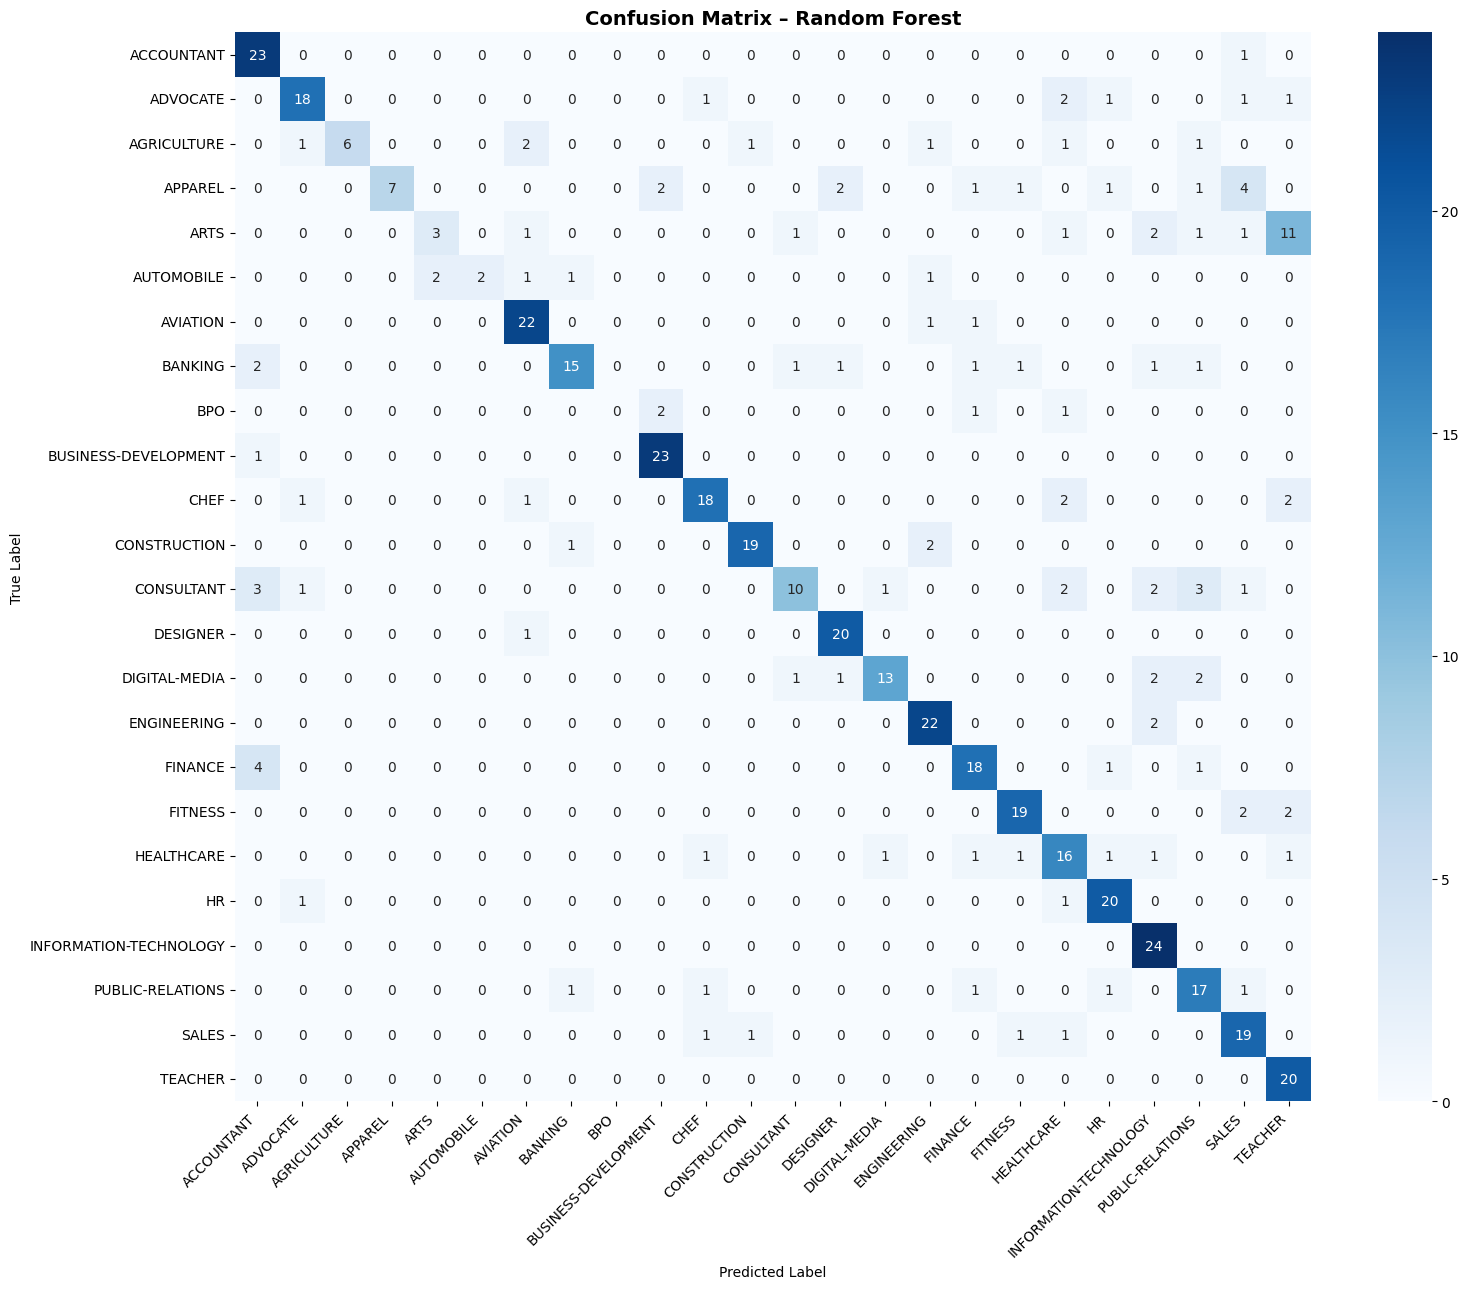


✅ Best TF-IDF Model: Random Forest | Accuracy: 75.25%


In [ ]:
# Confusion Matrix for Best TF-IDF Model (Logistic Regression)
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
best_preds = best_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix – {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print(f"\n✅ Best TF-IDF Model: {best_model_name} | Accuracy: {results[best_model_name]*100:.2f}%")

In [ ]:
# Top TF-IDF Keywords per Category
print("\n📌 Top 10 TF-IDF Keywords per Category:\n")
feature_names = tfidf.get_feature_names_out()

# Use Logistic Regression coefficients
lr_model = models['Logistic Regression']
for i, category in enumerate(le.classes_):
    top_indices = lr_model.coef_[i].argsort()[-10:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    print(f"  {category:25s}: {', '.join(top_words)}")


📌 Top 10 TF-IDF Keywords per Category:

  ACCOUNTANT               : accountant, accounting, accountant summary, reconciliation, ledger, bank, financial statement, financial, general ledger, reconciled
  ADVOCATE                 : advocate, child, health, care, court, patient, behavior, clinical, advocacy, assessment
  AGRICULTURE              : agriculture, agricultural, farmer, student, soil, government, extension, therapeutic, laboratory, research assistant
  APPAREL                  : apparel, merchandising, fashion, store, merchandise, stylist, inventory, sale, warehouse, buyer
  ARTS                     : art, art teacher, language art, music, creative, student, instructor, dental, always, professional development
  AUTOMOBILE               : automobile, inquiry, call center, auto, claim, customer service, fraud, repair, vehicle, card
  AVIATION                 : aviation, aircraft, flight, navy, maintenance, ammunition, repair, military, pilot, passenger
  BANKING              

**Bert Embeddings + Classification**

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression as LR

print("⏳ Loading BERT model (sentence-transformers/all-MiniLM-L6-v2)...")
bert_model = SentenceTransformer('all-mpnet-base-v2')
print("✅ BERT model loaded!")

⏳ Loading BERT model (sentence-transformers/all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ BERT model loaded!


In [ ]:
# Generate BERT embeddings (use truncated text for speed)
def truncate(text, max_words=150):
    return ' '.join(str(text).split()[:max_words])

print("⏳ Generating BERT embeddings for train set...")
X_train_bert = bert_model.encode(X_train.apply(truncate).tolist(),
                                  batch_size=32, show_progress_bar=True)

print("\n⏳ Generating BERT embeddings for test set...")
X_test_bert = bert_model.encode(X_test.apply(truncate).tolist(),
                                 batch_size=32, show_progress_bar=True)

print(f"\n✅ Embedding shape: {X_train_bert.shape}")

⏳ Generating BERT embeddings for train set...


Batches:   0%|          | 0/63 [00:00<?, ?it/s]


⏳ Generating BERT embeddings for test set...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


✅ Embedding shape: (1987, 768)


In [ ]:
# Classify using BERT embeddings
bert_classifier = LR(max_iter=1000, C=5, random_state=42)
bert_classifier.fit(X_train_bert, y_train)
bert_preds = bert_classifier.predict(X_test_bert)

bert_acc = accuracy_score(y_test, bert_preds)
print(f"\n{'='*50}")
print(f"  BERT + Logistic Regression Accuracy: {bert_acc*100:.2f}%")
print('='*50)
print(classification_report(y_test, bert_preds, target_names=le.classes_))


  BERT + Logistic Regression Accuracy: 69.82%
                        precision    recall  f1-score   support

            ACCOUNTANT       0.84      0.88      0.86        24
              ADVOCATE       0.61      0.58      0.60        24
           AGRICULTURE       0.86      0.46      0.60        13
               APPAREL       0.50      0.21      0.30        19
                  ARTS       0.47      0.43      0.45        21
            AUTOMOBILE       1.00      0.14      0.25         7
              AVIATION       0.84      0.67      0.74        24
               BANKING       0.54      0.65      0.59        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.79      0.92      0.85        24
                  CHEF       0.90      0.79      0.84        24
          CONSTRUCTION       0.77      0.77      0.77        22
            CONSULTANT       0.71      0.74      0.72        23
              DESIGNER       0.83      0.95      0.89   

In [ ]:
# ── NEW: TF-IDF + BERT Ensemble ──
from scipy.sparse import hstack, csr_matrix

X_train_combined = hstack([X_train_tfidf, csr_matrix(X_train_bert)])
X_test_combined  = hstack([X_test_tfidf,  csr_matrix(X_test_bert)])

ensemble_model = LogisticRegression(C=5, max_iter=1000, random_state=42)
ensemble_model.fit(X_train_combined, y_train)
ensemble_preds = ensemble_model.predict(X_test_combined)
ensemble_acc = accuracy_score(y_test, ensemble_preds)

print(f"TF-IDF + BERT Ensemble Accuracy: {ensemble_acc*100:.2f}%")
print(classification_report(y_test, ensemble_preds, target_names=le.classes_))

TF-IDF + BERT Ensemble Accuracy: 74.45%
                        precision    recall  f1-score   support

            ACCOUNTANT       0.75      0.88      0.81        24
              ADVOCATE       0.57      0.67      0.62        24
           AGRICULTURE       0.64      0.54      0.58        13
               APPAREL       0.67      0.32      0.43        19
                  ARTS       0.60      0.43      0.50        21
            AUTOMOBILE       1.00      0.14      0.25         7
              AVIATION       0.91      0.88      0.89        24
               BANKING       0.75      0.65      0.70        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.81      0.88      0.84        24
                  CHEF       0.90      0.79      0.84        24
          CONSTRUCTION       0.76      0.73      0.74        22
            CONSULTANT       0.77      0.87      0.82        23
              DESIGNER       0.90      0.86      0.88        21

⏳ Running t-SNE dimensionality reduction...


Batches:   0%|          | 0/78 [00:00<?, ?it/s]

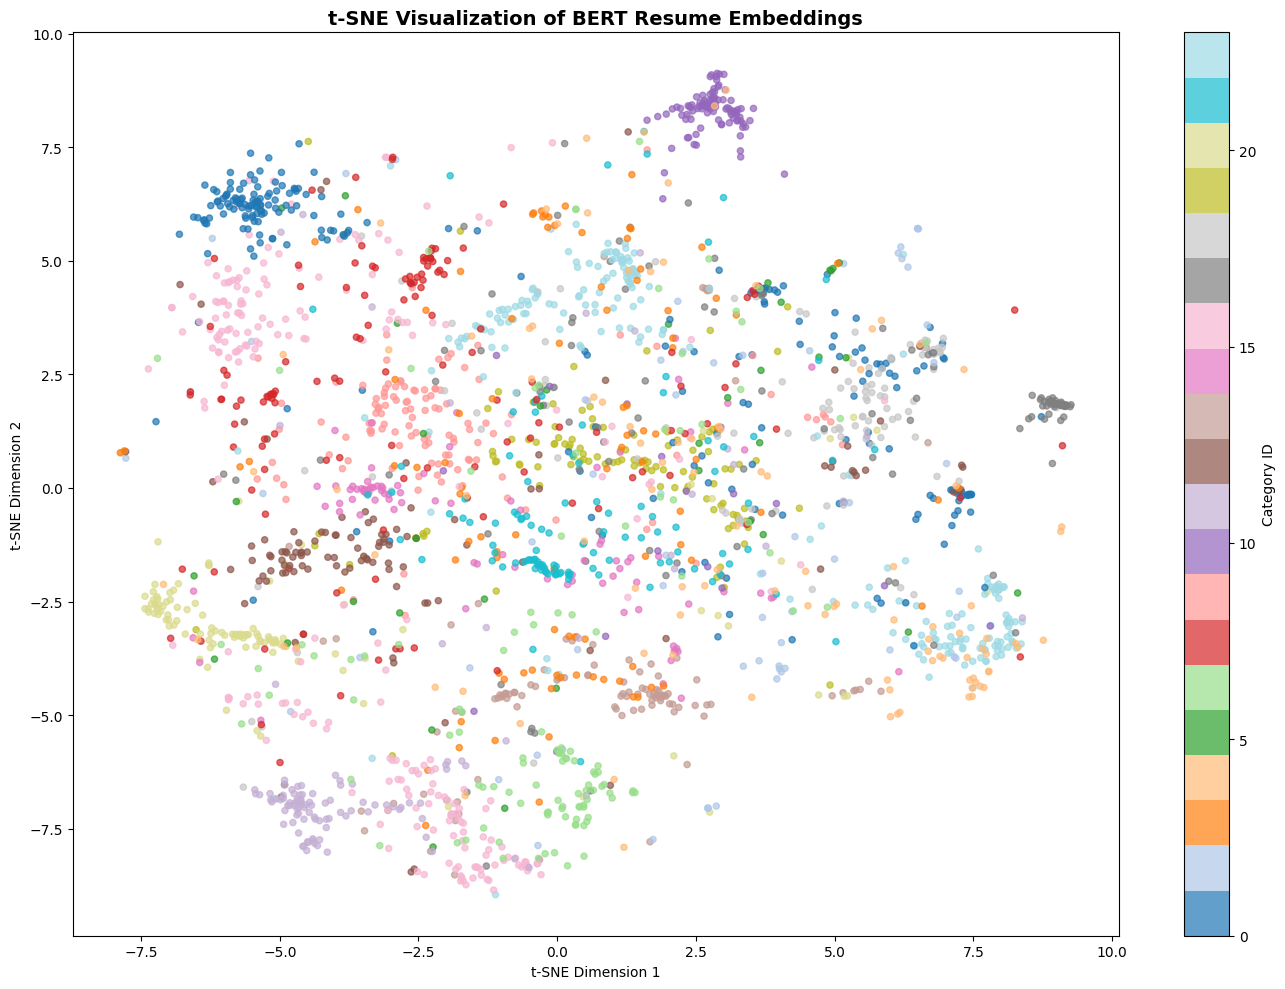

In [ ]:
# Visualize BERT embeddings with t-SNE
from sklearn.manifold import TSNE

print("⏳ Running t-SNE dimensionality reduction...")
all_embeddings = bert_model.encode(df['cleaned_resume'].apply(truncate).tolist(),
                                    batch_size=32, show_progress_bar=True)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
embeddings_2d = tsne.fit_transform(all_embeddings)

plt.figure(figsize=(14, 10))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      c=df['label'], cmap='tab20', alpha=0.7, s=20)
plt.colorbar(scatter, label='Category ID')
plt.title('t-SNE Visualization of BERT Resume Embeddings', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.tight_layout()
plt.show()

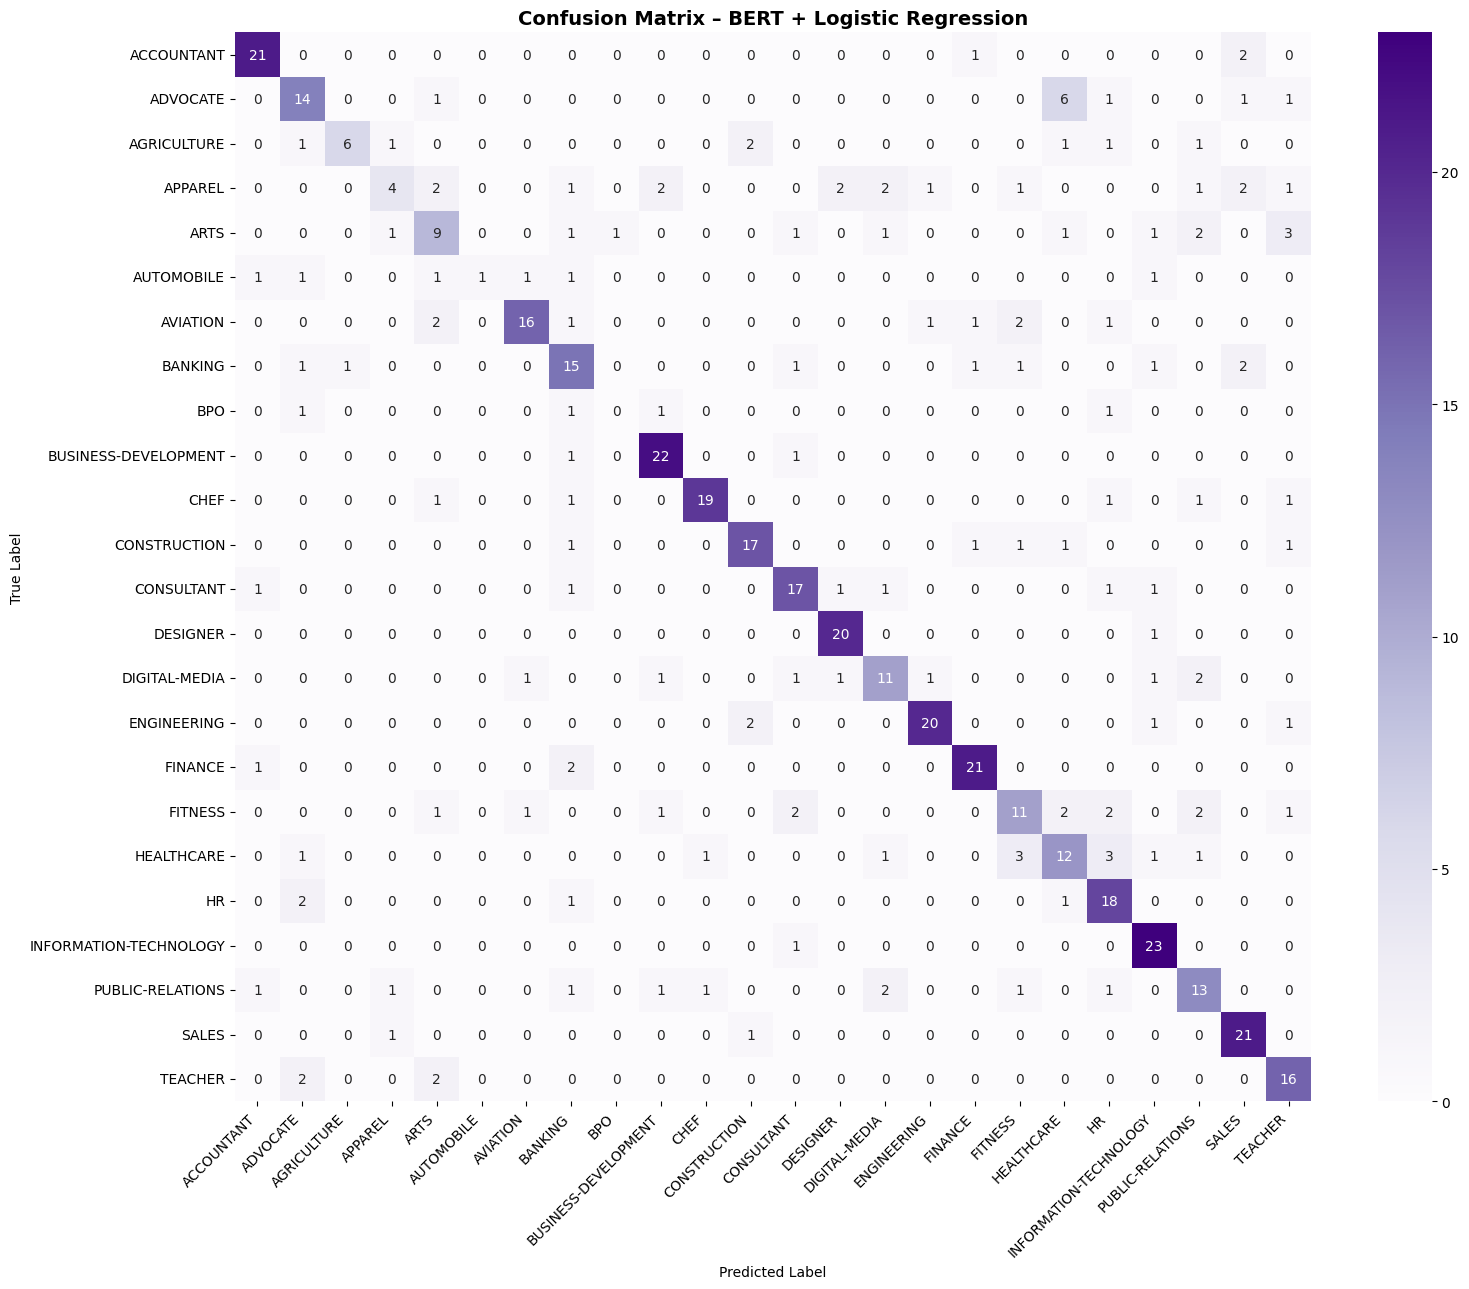

In [ ]:
# BERT Confusion Matrix
cm_bert = confusion_matrix(y_test, bert_preds)
plt.figure(figsize=(16, 13))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix – BERT + Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Cosine Similarity-Resume Matcher**

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Build career profile embeddings: average BERT embedding per category
print("⏳ Building career profile embeddings...")
career_profiles = {}
for category in df['Category'].unique():
    category_resumes = df[df['Category'] == category]['cleaned_resume'].apply(truncate).tolist()
    embeddings = bert_model.encode(category_resumes, batch_size=32)
    career_profiles[category] = embeddings.mean(axis=0)

career_names = list(career_profiles.keys())
career_vectors = np.array(list(career_profiles.values()))
print(f"✅ Career profiles built for {len(career_names)} categories.")

⏳ Building career profile embeddings...
✅ Career profiles built for 24 categories.


In [ ]:
def recommend_career(resume_text, top_n=5):
    """
    Given a resume text, recommend top N career paths
    using cosine similarity with BERT embeddings.
    """
    cleaned = clean_resume(resume_text)
    truncated = truncate(cleaned)
    resume_vec = bert_model.encode([truncated])
    similarities = cosine_similarity(resume_vec, career_vectors)[0]

    top_indices = similarities.argsort()[::-1][:top_n]
    results = []
    for idx in top_indices:
        results.append({
            'Career Path':   career_names[idx],
            'Similarity (%)': round(similarities[idx] * 100, 2)
        })
    return pd.DataFrame(results)

print("✅ Career recommendation function is ready!")

✅ Career recommendation function is ready!


In [ ]:
# ─── TEST: Run recommendation on a sample resume from the dataset ───
sample_resume = df['Resume_str'].iloc[10]
actual_category = df['Category'].iloc[10]

print(f"📄 Sample Resume (first 400 chars):\n{sample_resume[:400]}")
print(f"\n✅ Actual Category: {actual_category}")
print("\n🎯 Top 5 Career Recommendations (Cosine Similarity):")

recs = recommend_career(sample_resume, top_n=5)
display(recs)

📄 Sample Resume (first 400 chars):
         HR ASSISTANT       Summary    Highly motivated, and a dynamic Human Resources professional with diverse credentials seeking a position with a growing organization to make a positive impact on company policies, and experience career growth. Accomplished human resources and administrative professional with over 3 years' experience. Attentive to detail, able to take initiative, prioritize mu

✅ Actual Category: HR

🎯 Top 5 Career Recommendations (Cosine Similarity):


,Career Path,Similarity (%)
0,HR,87.279999
1,AUTOMOBILE,84.279999
2,ADVOCATE,82.800003
3,HEALTHCARE,82.720001
4,ARTS,82.610001


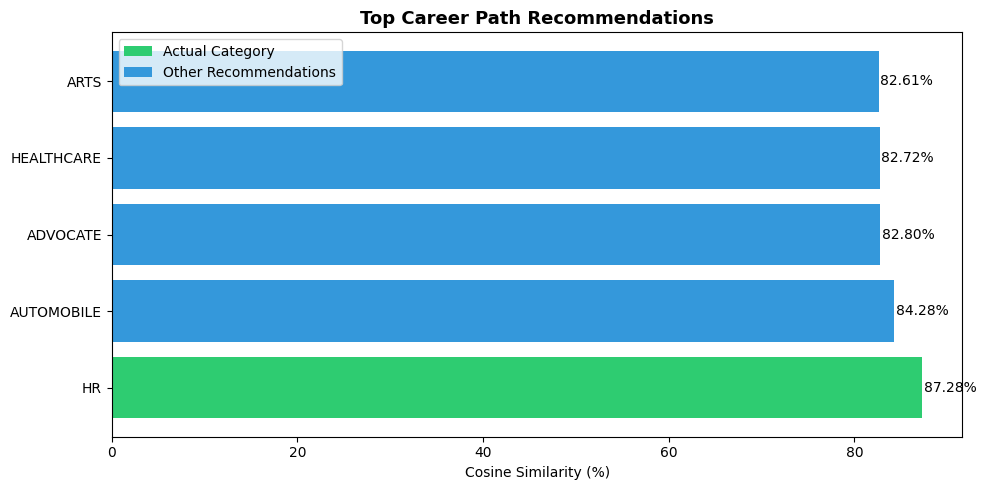

In [ ]:
# Visualize similarity scores
plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if c == actual_category else '#3498db' for c in recs['Career Path']]
bars = plt.barh(recs['Career Path'], recs['Similarity (%)'], color=colors)
plt.xlabel('Cosine Similarity (%)')
plt.title('Top Career Path Recommendations', fontsize=13, fontweight='bold')
for bar, val in zip(bars, recs['Similarity (%)']):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=10)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Actual Category'),
                   Patch(facecolor='#3498db', label='Other Recommendations')]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

**TF-IDF Cosine Similarity**

In [ ]:
# TF-IDF based career profile similarity
# Build one combined document per career category
tfidf_full = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
all_cleaned = df['cleaned_resume'].tolist()
tfidf_full.fit(all_cleaned)

# Create category-level TF-IDF profiles
tfidf_career_profiles = {}
for category in df['Category'].unique():
    docs = df[df['Category'] == category]['cleaned_resume'].tolist()
    combined = ' '.join(docs)
    tfidf_career_profiles[category] = tfidf_full.transform([combined]).toarray()[0]

tfidf_career_names = list(tfidf_career_profiles.keys())
tfidf_career_matrix = np.array(list(tfidf_career_profiles.values()))
print("✅ TF-IDF career profiles built!")

✅ TF-IDF career profiles built!


In [ ]:
def recommend_career_tfidf(resume_text, top_n=5):
    """
    Career recommendation using TF-IDF + Cosine Similarity.
    """
    cleaned = clean_resume(resume_text)
    resume_vec = tfidf_full.transform([cleaned]).toarray()
    similarities = cosine_similarity(resume_vec, tfidf_career_matrix)[0]

    top_indices = similarities.argsort()[::-1][:top_n]
    results = []
    for idx in top_indices:
        results.append({
            'Career Path':   tfidf_career_names[idx],
            'Similarity (%)': round(similarities[idx] * 100, 2)
        })
    return pd.DataFrame(results)

# Test it
print("🎯 Top 5 Career Recommendations (TF-IDF Cosine Similarity):")
tfidf_recs = recommend_career_tfidf(sample_resume, top_n=5)
display(tfidf_recs)

🎯 Top 5 Career Recommendations (TF-IDF Cosine Similarity):


,Career Path,Similarity (%)
0,HR,27.43
1,AUTOMOBILE,21.24
2,BPO,21.04
3,ACCOUNTANT,20.37
4,HEALTHCARE,20.26


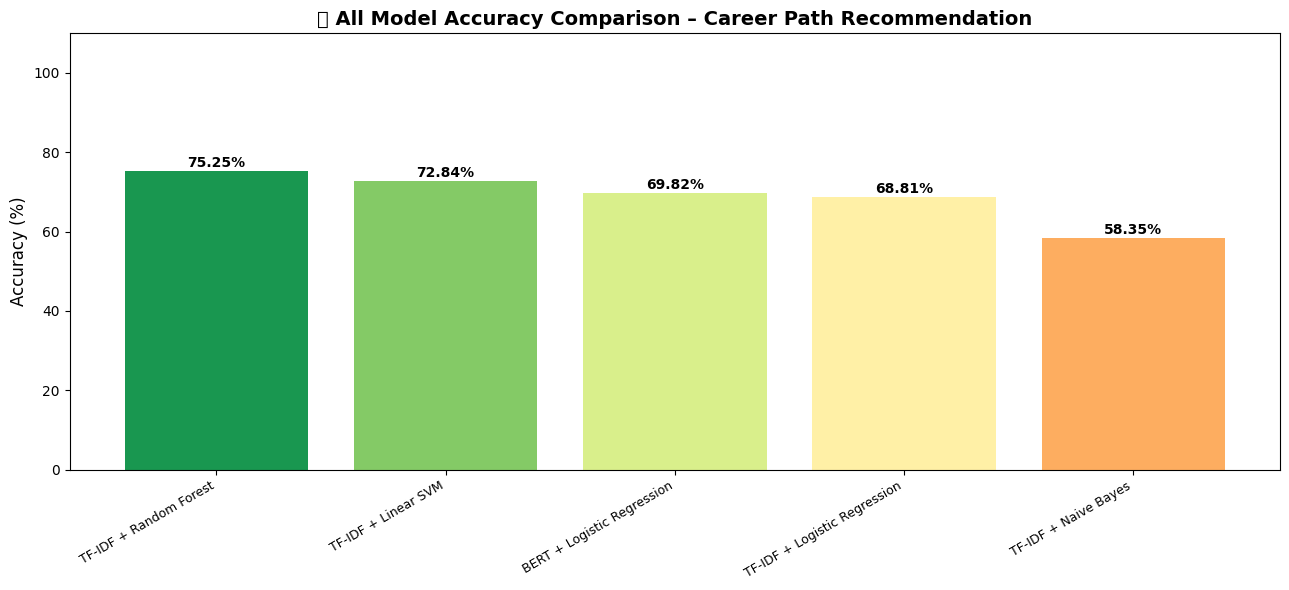


🏆 Best Overall Model: TF-IDF + Random Forest | Accuracy: 75.25%


In [ ]:
# Collect all accuracy scores
all_results = {
    **{f"TF-IDF + {k}": v for k, v in results.items()},
    'BERT + Logistic Regression': bert_acc
}

sorted_results = dict(sorted(all_results.items(), key=lambda x: x[1], reverse=True))

plt.figure(figsize=(13, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(sorted_results)))
bars = plt.bar(sorted_results.keys(), [v*100 for v in sorted_results.values()],
               color=colors[::-1])
plt.ylim(0, 110)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('📊 All Model Accuracy Comparison – Career Path Recommendation', fontsize=14, fontweight='bold')
for bar, val in zip(bars, sorted_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val*100:.2f}%', ha='center', fontsize=10, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

best_overall = max(sorted_results, key=sorted_results.get)
print(f"\n🏆 Best Overall Model: {best_overall} | Accuracy: {sorted_results[best_overall]*100:.2f}%")

In [ ]:
def full_career_recommendation(resume_text, top_n=5):
    """
    Full pipeline:
    1. TF-IDF ML Classification (fast prediction)
    2. BERT Cosine Similarity (semantic recommendation)
    3. TF-IDF Cosine Similarity (keyword-based recommendation)
    """
    cleaned = clean_resume(resume_text)

    # — TF-IDF ML Prediction —
    tfidf_vec = tfidf.transform([cleaned])
    ml_pred_label = best_model.predict(tfidf_vec)[0]
    ml_pred_category = le.inverse_transform([ml_pred_label])[0]

    # — BERT Cosine Similarity —
    bert_recs = recommend_career(resume_text, top_n)

    # — TF-IDF Cosine Similarity —
    tfidf_recs = recommend_career_tfidf(resume_text, top_n)

    print("="*60)
    print("     🎯 CAREER PATH RECOMMENDATION REPORT")
    print("="*60)
    print(f"\n🔵 TF-IDF + ML ({best_model_name}) Prediction:")
    print(f"   → {ml_pred_category}")

    print(f"\n🟣 BERT Semantic Similarity – Top {top_n} Career Paths:")
    display(bert_recs)

    print(f"\n🟢 TF-IDF Keyword Similarity – Top {top_n} Career Paths:")
    display(tfidf_recs)
    print("="*60)

# ─── Try your own resume text here! ───
my_resume = """
Experienced software engineer with 5 years of experience in Python, Java, and cloud technologies.
Strong background in machine learning, data pipelines, and REST API development.
Proficient with AWS, Docker, Kubernetes. Led a team of 4 engineers.
B.Tech Computer Science from IIT Bombay. Published 2 research papers in NLP.
"""

full_career_recommendation(my_resume, top_n=5)

     🎯 CAREER PATH RECOMMENDATION REPORT

🔵 TF-IDF + ML (Random Forest) Prediction:
   → BUSINESS-DEVELOPMENT

🟣 BERT Semantic Similarity – Top 5 Career Paths:


,Career Path,Similarity (%)
0,DIGITAL-MEDIA,66.459999
1,INFORMATION-TECHNOLOGY,63.090000
2,ENGINEERING,62.290001
3,BPO,62.119999
4,DESIGNER,61.320000



🟢 TF-IDF Keyword Similarity – Top 5 Career Paths:


,Career Path,Similarity (%)
0,ENGINEERING,9.09
1,CONSULTANT,7.66
2,INFORMATION-TECHNOLOGY,7.42
3,AGRICULTURE,6.92
4,AUTOMOBILE,6.86


In [ ]:
# ── Batch Evaluation: Cosine Similarity Top-1 Accuracy ──
print("⏳ Running batch cosine similarity evaluation on test set...")

correct_bert = 0
correct_tfidf = 0

test_df = df.iloc[X_test.index].reset_index(drop=True)

for i, row in test_df.iterrows():
    actual = row['Category']

    bert_top1 = recommend_career(row['Resume_str'], top_n=1)['Career Path'].values[0]
    tfidf_top1 = recommend_career_tfidf(row['Resume_str'], top_n=1)['Career Path'].values[0]

    if bert_top1 == actual:
        correct_bert += 1
    if tfidf_top1 == actual:
        correct_tfidf += 1

n = len(test_df)
print(f"\n✅ BERT Cosine Similarity  Top-1 Accuracy: {correct_bert/n*100:.2f}%")
print(f"✅ TF-IDF Cosine Similarity Top-1 Accuracy: {correct_tfidf/n*100:.2f}%")

⏳ Running batch cosine similarity evaluation on test set...

✅ BERT Cosine Similarity  Top-1 Accuracy: 63.78%
✅ TF-IDF Cosine Similarity Top-1 Accuracy: 87.32%


In [ ]:
df.to_csv('career_data.csv', index=False)